In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Loading the dataset

In [3]:
df = pd.read_csv("../dataset/Lucy_english_dataset.csv")

In [4]:
df.head()

,text,emotion
0,i feel rather funny ending with so many dupes ...,fun
1,i feel surprised by the result,surprise
2,i am officially feeling festive,neutral
3,i suddenly found myself standing before this w...,surprise
4,i look at the meager pile of food i purchased ...,enthusiasm


In [5]:
df['emotion'].value_counts()

emotion
fun           10000
surprise      10000
enthusiasm    10000
happiness     10000
hate          10000
love          10000
relief        10000
anger         10000
sadness        9999
neutral        9998
empty          6358
Name: count, dtype: int64

# Selecting the emotions 

In [6]:
selected_emotions = ["happiness", "sadness", "anger","surprise","love","enthusiasm","hate"]
df = df[df["emotion"].isin(selected_emotions)]

In [7]:
emotion_map = {
    "happiness": "happy",
    "sadness": "sad",
    "anger": "angry",
    "surprise":"surprise",
    "love":"love",
    "hate":"hate",
    "enthusiasm":"enthusiasm"
}

df["emotion"] = df["emotion"].map(emotion_map)

In [8]:
df

,text,emotion
1,i feel surprised by the result,surprise
3,i suddenly found myself standing before this w...,surprise
4,i look at the meager pile of food i purchased ...,enthusiasm
5,"I, for one, am thrilled that Christ works outs...",happy
6,i hate that she has the power to make me feel ...,hate
...,...,...
106348,i feel so imcomplete and eager to accomplish s...,enthusiasm
106350,i used to feel strongly about how much i hated...,hate
106351,i feel like i just got a spirit booster this r...,surprise
106352,i could come up with is that i was really feel...,angry


In [9]:
df['emotion'].unique()

<StringArray>
['surprise', 'enthusiasm', 'happy', 'hate', 'sad', 'love', 'angry']
Length: 7, dtype: str

# EDA 

In [10]:
df.info()

<class 'pandas.DataFrame'>
Index: 69999 entries, 1 to 106354
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   text     69999 non-null  str  
 1   emotion  69999 non-null  str  
dtypes: str(2)
memory usage: 1.6 MB


In [11]:
df.isnull().sum()

text       0
emotion    0
dtype: int64

In [12]:
df.shape

(69999, 2)

In [13]:
df.describe()

,text,emotion
count,69999,69999
unique,53871,7
top,"RT, follow and WIN one of the 5 special collec...",surprise
freq,23,10000


In [14]:
df.duplicated().sum()

np.int64(16106)

In [15]:
df.duplicated(subset=["text"]).sum()

np.int64(16128)

In [16]:
df.groupby("text")["emotion"].nunique().sort_values(ascending=False).head()


text
FREE UNLIMITED RINGTONES!!! - - USA ONLY - Awesome 4 iphone                                                                3
Thank you!                                                                                                                 3
Happy Mothers Day                                                                                                          2
Its raining on Staunton again, We need the rain, but that just means Ive got nothing sitting outside for people to see,    2
Thanks                                                                                                                     2
Name: emotion, dtype: int64

# Removing Dublicates

In [17]:
df = df.drop_duplicates()

In [18]:
df.duplicated().sum()

np.int64(0)

## Removig Conflicts Emotion

In [19]:
valid_texts = df.groupby("text")["emotion"].nunique()
valid_texts = valid_texts[valid_texts == 1].index

df = df[df["text"].isin(valid_texts)]

In [20]:
df.groupby("text")["emotion"].nunique().sort_values(ascending=False).head()

text
! HE HAS A FAVOURITE! You're his favourite ;) OMGAAH. sorry for creepering? really lol    1
! RT : C'est confirmé! Nous aurons toute une activité pour la de ! Détails à venir!       1
! please follow so that we can keep our updates and stuff there use it to spread word     1
!! ... maybe they took one look at you and said &quot;That's our girl!&quot;              1
!!! Tell us your experience! I Loveeeee Youu!                                             1
Name: emotion, dtype: int64

In [21]:
df.shape

(53851, 2)

In [22]:
df['emotion'].value_counts()

emotion
sad           9306
happy         9145
love          8579
surprise      7909
angry         7462
hate          6205
enthusiasm    5245
Name: count, dtype: int64

<Axes: xlabel='emotion', ylabel='count'>

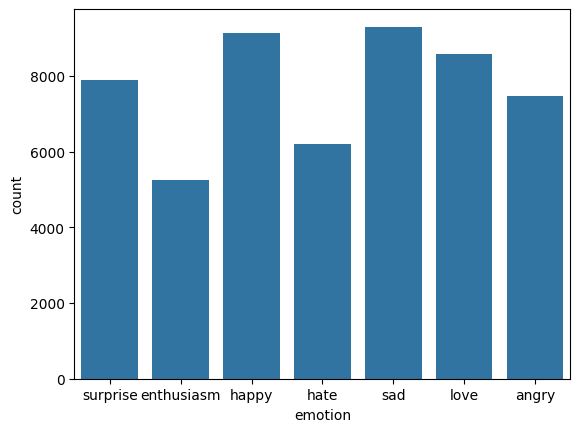

In [23]:
sns.countplot(x="emotion", data=df)

In [24]:
df["text_length"] = df["text"].apply(len)
df["text_length"].describe()

count    53851.000000
mean       100.074149
std         56.925580
min          3.000000
25%         58.000000
50%         90.000000
75%        129.000000
max        830.000000
Name: text_length, dtype: float64

# Test Train Split

In [25]:
X = df['text']
y = df['emotion']

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42,stratify=y)

# Creating Pipeline 

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV

In [29]:
pipeline = Pipeline([
    ("tfidf" , TfidfVectorizer()),
    ("model",LogisticRegression())
])

### Parameters for Grid Search CV

In [30]:
param_grid = [

    {
        "tfidf__lowercase": [True],
        "tfidf__stop_words": ["english"],
        "tfidf__ngram_range": [(1,2)],
        "tfidf__max_features": [9000,10000],
        "tfidf__min_df": [2],
        "tfidf__max_df": [0.9],

        "model": [LogisticRegression()],
        "model__C": [0.8,1,1.2],
        "model__solver": ["liblinear","saga"],
        "model__max_iter": [1000],
        "model__class_weight": ["balanced"]
    },

    {
        "tfidf__lowercase": [True],
        "tfidf__stop_words": ["english"],
        "tfidf__ngram_range": [(1,2)],
        "tfidf__max_features": [9000,10000],
        "tfidf__min_df": [2],
        "tfidf__max_df": [0.9],

        "model": [SVC()],
        "model__C": [0.5,1,2],
        "model__class_weight": ["balanced"]
    }

]

## Applying Grid  Search CV

In [31]:
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2
)

In [32]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


KeyboardInterrupt: 

In [ ]:
print(grid.best_params_)

{'model': LogisticRegression(), 'model__C': 1, 'model__class_weight': 'balanced', 'model__max_iter': 1000, 'model__solver': 'saga', 'tfidf__lowercase': True, 'tfidf__max_df': 0.9, 'tfidf__max_features': 10000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2), 'tfidf__stop_words': 'english'}


In [ ]:
best_model = grid.best_estimator_


In [ ]:
y_predict = best_model.predict(X_test)

# Classifiaction Report 

In [ ]:
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

       angry       0.83      0.83      0.83      1493
  enthusiasm       0.95      0.84      0.89      1049
       happy       0.79      0.76      0.77      1829
        hate       0.84      0.82      0.83      1241
        love       0.91      0.89      0.90      1716
         sad       0.69      0.71      0.70      1861
    surprise       0.65      0.74      0.69      1582

    accuracy                           0.79     10771
   macro avg       0.81      0.80      0.80     10771
weighted avg       0.80      0.79      0.79     10771



In [ ]:
import joblib

In [ ]:
joblib.dump(best_model,"../models/lucy_pipeline_v0_03.pkl")

['../models/lucy_pipeline_v0_03.pkl']